In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR = Path("../data/raw")
customers = pd.read_csv(RAW_DIR / "customers.csv", na_values=["", "NA", "N/A", "-", ".", "null", "NULL"])
support = pd.read_csv(RAW_DIR / "customer_support.csv", na_values=["", "NA", "N/A", "-", ".", "null", "NULL"])
mkt = pd.read_csv(RAW_DIR / "marketing_touchpoints.csv", na_values=["", "NA", "N/A", "-", ".", "null", "NULL"])

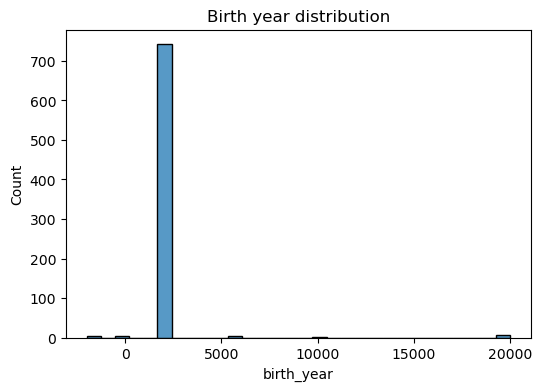

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(customers["birth_year"], bins=30, kde=False)
plt.title("Birth year distribution")
plt.show()

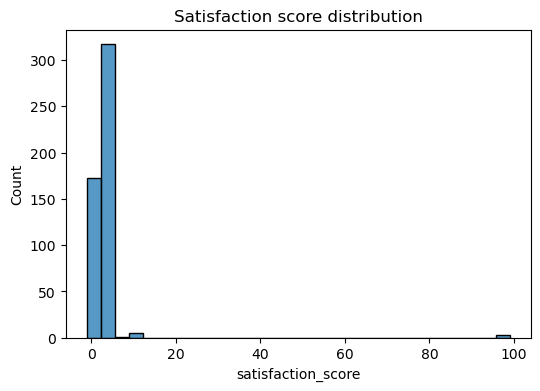

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(support["satisfaction_score"], bins=30, kde=False)
plt.title("Satisfaction score distribution")
plt.show()

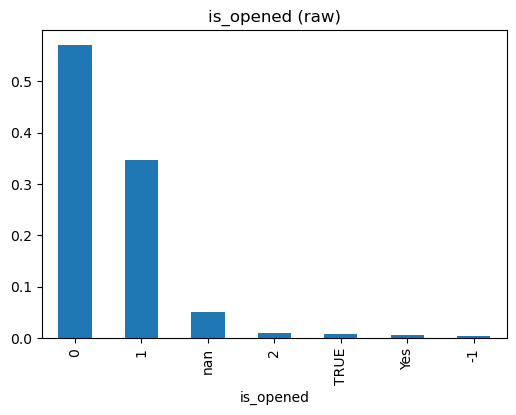

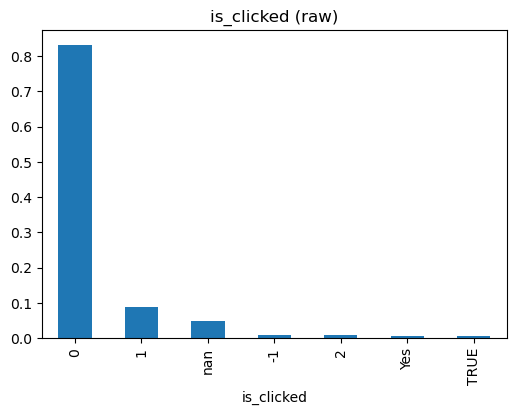

In [7]:
mkt["is_opened"].value_counts(dropna=False)
mkt["is_clicked"].value_counts(dropna=False)

plt.figure(figsize=(6,4))
mkt["is_opened"].value_counts(normalize=True, dropna=False).plot(kind="bar")
plt.title("is_opened (raw)")
plt.show()

plt.figure(figsize=(6,4))
mkt["is_clicked"].value_counts(normalize=True, dropna=False).plot(kind="bar")
plt.title("is_clicked (raw)")
plt.show()

### Cleaning rules derived from EDA

- `is_opened`: Standardize binary values by mapping {1, '1', 'Yes', 'TRUE'} to 1
  and {0, '0', 'No', 'FALSE'} to 0; treat other values (2, -1, unknown strings)
  as missing.
- `is_clicked`: Apply the same mapping as `is_opened` and enforce the rule
  `is_clicked <= is_opened` by setting `is_opened = 1` whenever `is_clicked = 1`.
- `birth_year`: Keep only plausible years (1900–2010); convert invalid values
  such as 0, negatives, 5000, 10000, 20000 to missing, then impute with the
  median and add a missingness flag.
- `satisfaction_score`: Keep only values in [1, 5]; convert 0, -1, 10, 99 to
  missing; allow missing scores for `Pending` tickets.
- `channel`: Normalize known channels and map invalid values such as `Pigeon`,
  `Fax`, `null` to `Unknown`.
- `date columns`: Parse all date fields with coercion, turning malformed dates
  like `0000-00-00` into missing.

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/raw")
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

customers = pd.read_csv(DATA_DIR / "customers.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
transaction_items = pd.read_csv(DATA_DIR / "transaction_items.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
support = pd.read_csv(DATA_DIR / "customer_support.csv")
marketing = pd.read_csv(DATA_DIR / "marketing_touchpoints.csv")
stores = pd.read_csv(DATA_DIR / "stores.csv")

In [33]:
def clean_binary_flag(x):
    """Chuẩn hóa cờ nhị phân về {0,1} từ các dạng 0/1, Yes/No, TRUE/FALSE."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ["1", "yes", "true"]:
        return 1
    if x in ["0", "no", "false"]:
        return 0
    return np.nan

def parse_date(series):
    """Parse date với errors='coerce'."""
    return pd.to_datetime(series, errors="coerce")

In [34]:
# --- binary flags ---
marketing["is_opened_clean"] = marketing["is_opened"].apply(clean_binary_flag)
marketing["is_clicked_clean"] = marketing["is_clicked"].apply(clean_binary_flag)

# Enforce is_clicked <= is_opened
marketing.loc[marketing["is_clicked_clean"] == 1, "is_opened_clean"] = 1

# Optional: fill NaN (có thể giữ NaN nếu bạn muốn)
marketing["is_opened_clean"] = marketing["is_opened_clean"].fillna(0)
marketing["is_clicked_clean"] = marketing["is_clicked_clean"].fillna(0)

# --- channel chuẩn hóa ---
valid_mkt_channels = [
    "Email", "SMS", "Push Notification", "Facebook Ad", "Zalo OA", "In-app", "Flash Sale"
]
marketing["channel_clean"] = marketing["channel"].where(
    marketing["channel"].isin(valid_mkt_channels), "Unknown"
)

# --- sent_date ---
marketing["sent_date_clean"] = parse_date(marketing["sent_date"])

# Lưu bản cleaned của marketing
marketing_clean = marketing.copy()
marketing_clean.to_csv(OUTPUT_DIR / "marketing_touchpoints_clean.csv", index=False)

In [35]:
customers["birth_year"] = pd.to_numeric(customers["birth_year"], errors="coerce")

# Giữ năm sinh trong khoảng hợp lý (vd: 1900–2010)
valid_birth_mask = customers["birth_year"].between(1900, 2010)
customers.loc[~valid_birth_mask, "birth_year"] = np.nan

customers["birth_year_missing_flag"] = customers["birth_year"].isna().astype(int)

# Impute bằng median
median_birth_year = customers["birth_year"].median()
customers["birth_year"] = customers["birth_year"].fillna(median_birth_year)

# Ngày đăng ký
if "registration_date" in customers.columns:
    customers["registration_date_clean"] = parse_date(customers["registration_date"])

customers_clean = customers.copy()
customers_clean.to_csv(OUTPUT_DIR / "customers_clean.csv", index=False)

In [36]:
# satisfaction_score
support["satisfaction_score"] = pd.to_numeric(
    support["satisfaction_score"], errors="coerce"
)

# Giữ 1–5, còn lại NaN
valid_score_mask = support["satisfaction_score"].between(1, 5)
support.loc[~valid_score_mask, "satisfaction_score"] = np.nan

# channel
valid_support_channels = [
    "Email", "Chat", "Hotline", "Facebook", "Zalo", "Ti ca hng", "Tại cửa hàng"
]
support["channel_clean"] = support["channel"].where(
    support["channel"].isin(valid_support_channels), "Unknown"
)

# created_date
if "created_date" in support.columns:
    support["created_date_clean"] = parse_date(support["created_date"])

# Flag trường hợp "Pending" nhưng có score (để nêu trong báo cáo)
support["pending_with_score_flag"] = (
    (support["resolution_status"] == "Pending")
    & support["satisfaction_score"].notna()
).astype(int)

support_clean = support.copy()
support_clean.to_csv(OUTPUT_DIR / "customer_support_clean.csv", index=False)

In [37]:
# transactions dates
for col in ["transaction_date"]:
    if col in transactions.columns:
        transactions[f"{col}_clean"] = parse_date(transactions[col])

# transaction_items: ép kiểu số, đặt <= 0 thành NaN
for col in ["quantity", "unit_price"]:
    if col in transaction_items.columns:
        transaction_items[col] = pd.to_numeric(transaction_items[col], errors="coerce")
        transaction_items.loc[transaction_items[col] <= 0, col] = np.nan

# Tạo bản sao và DROP các dòng thiếu quantity hoặc unit_price
transaction_items_clean = transaction_items.copy()
transaction_items_clean = transaction_items_clean.dropna(subset=["quantity", "unit_price"])

# Sao chép transactions sau khi thêm transaction_date_clean
transactions_clean = transactions.copy()

# Ghi ra file
transaction_items_clean.to_csv(OUTPUT_DIR / "transaction_items_clean.csv", index=False)
transactions_clean.to_csv(OUTPUT_DIR / "transactions_clean.csv", index=False)

# products, stores thường ít lỗi; bạn có thể chỉ parse date, chuẩn hóa text nếu cần
stores["opened_date_clean"] = parse_date(stores["opened_date"])
stores_clean = stores.copy()
stores_clean.to_csv(OUTPUT_DIR / "stores_clean.csv", index=False)

products_clean = products.copy()
products_clean.to_csv(OUTPUT_DIR / "products_clean.csv", index=False)

In [38]:
# ════════════════════════════════════════════════════════════════
# MISSING VALUES — Chiến lược rõ ràng theo từng bảng
# ════════════════════════════════════════════════════════════════

# ── customers ──────────────────────────────────────────────────
# gender: categorical → impute bằng mode (không drop vì chỉ 5.4%)
customers["gender"] = customers["gender"].fillna(customers["gender"].mode()[0])

# city, acquisition_channel: categorical → giữ NaN thành 'Unknown'
# (không impute vì không có cơ sở dự đoán location)
customers["city"] = customers["city"].fillna("Unknown")
customers["acquisition_channel"] = customers["acquisition_channel"].fillna("Unknown")

# registration_date: chỉ 2% thiếu → drop các dòng này
# (ngày đăng ký là dữ liệu gốc, không impute được)
customers = customers.dropna(subset=["registration_date"])
print(f"customers sau drop missing registration_date: {len(customers)} rows")

# ── transactions ───────────────────────────────────────────────
# payment_method: categorical 5.4% → impute mode
transactions["payment_method"] = transactions["payment_method"].fillna(
    transactions["payment_method"].mode()[0]
)

# discount_applied: 4.7% → impute bằng 0 (giả định không có giảm giá)
transactions["discount_applied"] = transactions["discount_applied"].fillna(0)

# ── transaction_items ──────────────────────────────────────────
# quantity, unit_price: ~5% → drop dòng (không thể tính revenue nếu thiếu)
items_before = len(transaction_items)
transaction_items = transaction_items.dropna(subset=["quantity", "unit_price"])
print(f"transaction_items: dropped {items_before - len(transaction_items)} rows missing qty/price")

# ── marketing_touchpoints ──────────────────────────────────────
# offer_value: 5.2% → impute bằng 0 (không có offer = offer = 0)
marketing["offer_value"] = marketing["offer_value"].fillna(0)

# channel: 5.6% → đã map Unknown ở trên, giữ nguyên
# is_opened, is_clicked: đã xử lý ở clean_binary_flag fillna(0)

# ── customer_support ───────────────────────────────────────────
# satisfaction_score: 28.9% thiếu → KHÔNG impute
# (vì missing có nghĩa: ticket chưa đánh giá, impute sẽ sai lệch phân tích)
# Giữ NaN — chỉ dùng khi tính avg_satisfaction với skipna=True

# issue_type: 6% → impute "Unknown"
support["issue_type"] = support["issue_type"].fillna("Unknown")

# channel: 4.1% → impute "Unknown"
support["channel"] = support["channel"].fillna("Unknown")

# ── products ───────────────────────────────────────────────────
# brand: 6% thiếu → impute "Unknown Brand"
products["brand"] = products["brand"].fillna("Unknown Brand")

print("✅ Missing values handled")

customers sau drop missing registration_date: 784 rows
transaction_items: dropped 794 rows missing qty/price
✅ Missing values handled


In [39]:
# ════════════════════════════════════════════════════════════════
# GIÁ TRỊ KHÔNG HỢP LỆ
# ════════════════════════════════════════════════════════════════

# ── gender: 'X', '0', 'Unknown' → map về 'Other' ──────────────
valid_genders = ['M', 'F', 'Other']
customers["gender_clean"] = customers["gender"].where(
    customers["gender"].isin(valid_genders), "Other"
)
print("gender value counts sau clean:")
print(customers["gender_clean"].value_counts())

# ── payment_method: 'Bitcoin', '???', 'Unknown' → 'Other' ──────
valid_payments = ['Cash', 'Credit Card', 'Bank Transfer', 'VNPay', 'ZaloPay', 'Momo']
transactions["payment_method_clean"] = transactions["payment_method"].where(
    transactions["payment_method"].isin(valid_payments), "Other"
)
print("\npayment_method value counts sau clean:")
print(transactions["payment_method_clean"].value_counts())

gender value counts sau clean:
gender_clean
M        411
F        355
Other     18
Name: count, dtype: int64

payment_method value counts sau clean:
payment_method_clean
Momo             789
Credit Card      597
ZaloPay          595
VNPay            576
Bank Transfer    571
Cash             270
Other            102
Name: count, dtype: int64


In [40]:
# ════════════════════════════════════════════════════════════════
# LOGIC CONSISTENCY: Pending ticket không được có satisfaction
# ════════════════════════════════════════════════════════════════

# Đếm vi phạm
pending_with_score = (
    (support["resolution_status"] == "Pending") &
    support["satisfaction_score"].notna()
).sum()
print(f"Pending tickets có satisfaction_score: {pending_with_score}")

# Fix: set về NaN (logic: Pending = chưa giải quyết = không có đánh giá)
support.loc[support["resolution_status"] == "Pending", "satisfaction_score"] = np.nan
print("✅ Đã xóa satisfaction_score của Pending tickets")

# Kiểm tra lại
assert (
    (support["resolution_status"] == "Pending") &
    support["satisfaction_score"].notna()
).sum() == 0, "Vẫn còn Pending có score!"
print("✅ Logic check passed")

Pending tickets có satisfaction_score: 0
✅ Đã xóa satisfaction_score của Pending tickets
✅ Logic check passed


### Cleaning summary

- `marketing.is_opened` and `marketing.is_clicked` contained multiple encodings
  (`Yes`, `TRUE`, `2`, `-1`). We standardized them to binary flags {0,1} using a
  unified mapping function and enforced the business rule `is_clicked <= is_opened`.
- `customers.birth_year` had impossible values (0, negatives, very large years).
  We kept only years between 1900 and 2010, set invalid values to missing, then
  imputed with the median and added a missingness flag.
- `customer_support.satisfaction_score` was designed to be on a 1–5 scale but
  included values such as 0, 10, 99 and -1. We treated these as invalid and set
  them to missing. Pending tickets were allowed to have missing scores.
- All date fields were parsed with `errors='coerce'`, converting malformed dates
  like `0000-00-00` or `NaT`-like strings into missing values.
- Categorical channels in both marketing and support were normalized to a
  whitelist of valid channels, with others mapped to `Unknown`.

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR.parent / "data" / "processed"

customers = pd.read_csv(PROCESSED_DIR / "customers_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "transactions_clean.csv")
transaction_items = pd.read_csv(PROCESSED_DIR / "transaction_items_clean.csv")
products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
support = pd.read_csv(PROCESSED_DIR / "customer_support_clean.csv")
marketing = pd.read_csv(PROCESSED_DIR / "marketing_touchpoints_clean.csv")
stores = pd.read_csv(PROCESSED_DIR / "stores_clean.csv")

In [17]:
def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_", regex=False)
    )
    return df

customers = normalize_columns(customers)
transactions = normalize_columns(transactions)
transaction_items = normalize_columns(transaction_items)
products = normalize_columns(products)
support = normalize_columns(support)
marketing = normalize_columns(marketing)
stores = normalize_columns(stores)

for name, df in {
    "customers": customers,
    "transactions": transactions,
    "transaction_items": transaction_items,
    "products": products,
    "support": support,
    "marketing": marketing,
    "stores": stores
}.items():
    print(name, df.columns.tolist())

customers ['customer_id', 'gender', 'birth_year', 'city', 'registration_date', 'acquisition_channel', 'birth_year_missing_flag', 'registration_date_clean']
transactions ['transaction_id', 'customer_id', 'transaction_date', 'store_id', 'payment_method', 'discount_applied', 'transaction_date_clean']
transaction_items ['transaction_id', 'product_id', 'quantity', 'unit_price']
products ['product_id', 'product_name', 'category', 'sub_category', 'brand', 'base_price']
support ['ticket_id', 'customer_id', 'created_date', 'channel', 'issue_type', 'resolution_status', 'satisfaction_score', 'channel_clean', 'created_date_clean', 'pending_with_score_flag']
marketing ['campaign_id', 'customer_id', 'sent_date', 'channel', 'campaign_type', 'is_opened', 'is_clicked', 'offer_value', 'is_opened_clean', 'is_clicked_clean', 'channel_clean', 'sent_date_clean']
stores ['store_id', 'store_name', 'city', 'store_type', 'opened_date', 'opened_date_clean']


In [18]:
date_cols = {
    "customers": ["registration_date", "registration_date_clean"],
    "transactions": ["transaction_date", "transaction_date_clean"],
    "support": ["created_date", "created_date_clean"],
    "marketing": ["sent_date", "sent_date_clean"],
    "stores": ["opened_date", "opened_date_clean"]
}

for col in date_cols["transactions"]:
    if col in transactions.columns:
        transactions[col] = pd.to_datetime(transactions[col], errors="coerce")

for col in date_cols["customers"]:
    if col in customers.columns:
        customers[col] = pd.to_datetime(customers[col], errors="coerce")

for col in date_cols["support"]:
    if col in support.columns:
        support[col] = pd.to_datetime(support[col], errors="coerce")

for col in date_cols["marketing"]:
    if col in marketing.columns:
        marketing[col] = pd.to_datetime(marketing[col], errors="coerce")

for col in date_cols["stores"]:
    if col in stores.columns:
        stores[col] = pd.to_datetime(stores[col], errors="coerce")

In [19]:
transaction_items["quantity"] = pd.to_numeric(transaction_items["quantity"], errors="coerce")
transaction_items["unit_price"] = pd.to_numeric(transaction_items["unit_price"], errors="coerce")

transaction_items["item_amount"] = transaction_items["quantity"] * transaction_items["unit_price"]

tx_amount = (
    transaction_items
    .groupby("transaction_id", as_index=False)
    .agg(
        gross_amount=("item_amount", "sum"),
        total_items=("quantity", "sum"),
        unique_products=("product_id", "nunique")
    )
)

tx_amount.head()

,transaction_id,gross_amount,total_items,unique_products
0,T000001,1710000.0,5.0,1
1,T000002,149082000.0,14.0,2
2,T000003,4836000.0,2.0,1
3,T000004,5687000.0,13.0,4
4,T000005,71016000.0,8.0,4


In [20]:
transactions["discount_applied"] = pd.to_numeric(transactions["discount_applied"], errors="coerce")
transactions["discount_applied"] = transactions["discount_applied"].fillna(0)
transactions["discount_applied"] = transactions["discount_applied"].clip(0, 1)

transactions_enriched = transactions.merge(
    tx_amount,
    on="transaction_id",
    how="left"
)

transactions_enriched["gross_amount"] = transactions_enriched["gross_amount"].fillna(0)
transactions_enriched["total_items"] = transactions_enriched["total_items"].fillna(0)
transactions_enriched["unique_products"] = transactions_enriched["unique_products"].fillna(0)

transactions_enriched["total_amount"] = (
    transactions_enriched["gross_amount"] * (1 - transactions_enriched["discount_applied"])
)

transactions_enriched[[
    "transaction_id", "customer_id", "gross_amount", "discount_applied", "total_amount"
]].head()

,transaction_id,customer_id,gross_amount,discount_applied,total_amount
0,T000001,C00301,1710000.0,0.20,1368000.0
1,T000002,C00109,149082000.0,0.00,149082000.0
2,T000003,C00008,4836000.0,0.00,4836000.0
3,T000004,C00754,5687000.0,0.15,4833950.0
4,T000005,C00268,71016000.0,0.05,67465200.0


In [21]:
transaction_fact = transactions_enriched.merge(
    stores,
    on="store_id",
    how="left",
    suffixes=("", "_store")
)

transaction_fact.head()

,transaction_id,customer_id,transaction_date,store_id,payment_method,discount_applied,transaction_date_clean,gross_amount,total_items,unique_products,total_amount,store_name,city,store_type,opened_date,opened_date_clean
0,T000001,C00301,2025-01-01,S018,Bank Transfer,0.20,2025-01-01,1710000.0,5.0,1,1368000.0,Store_B8,Bắc Ninh,offline,2020-06-10,2020-06-10
1,T000002,C00109,2026-01-07,S014,VNPay,0.00,2026-01-07,149082000.0,14.0,2,149082000.0,Store_B4,Nha Trang,online,2020-07-08,2020-07-08
2,T000003,C00008,2024-11-29,S007,ZaloPay,0.00,2024-11-29,4836000.0,2.0,1,4836000.0,Store_A7,Hà Nội,online,2020-03-06,2020-03-06
3,T000004,C00754,2025-02-26,S010,Cash,0.15,2025-02-26,5687000.0,13.0,4,4833950.0,Store_B0,Huế,offline,2021-03-27,2021-03-27
4,T000005,C00268,2025-06-29,S023,ZaloPay,0.05,2025-06-29,71016000.0,8.0,4,67465200.0,Store_C3,Nha Trang,offline,2020-07-25,2020-07-25


In [22]:
item_detail = transaction_items.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("", "_product")
)

item_detail = item_detail.merge(
    transactions[["transaction_id", "customer_id", "store_id", "transaction_date", "transaction_date_clean", "discount_applied"]],
    on="transaction_id",
    how="left"
)

item_detail.head()

,transaction_id,product_id,quantity,unit_price,item_amount,product_name,category,sub_category,brand,base_price,customer_id,store_id,transaction_date,transaction_date_clean,discount_applied
0,T000001,P0107,5.0,342000.0,1710000.0,Thực phẩm khô_107,Thực phẩm,Thực phẩm khô,TH True,342000.0,C00301,S018,2025-01-01,2025-01-01,0.20
1,T000002,P0028,4.0,4673000.0,18692000.0,Tablet_28,Điện tử,Tablet,LG,4673000.0,C00109,S014,2026-01-07,2026-01-07,0.00
2,T000002,P0007,10.0,13039000.0,130390000.0,Laptop_7,Điện tử,Laptop,Samsung,13039000.0,C00109,S014,2026-01-07,2026-01-07,0.00
3,T000003,P0065,2.0,2418000.0,4836000.0,Nhà bếp_65,Gia dụng,Nhà bếp,Generic,2418000.0,C00008,S007,2024-11-29,2024-11-29,0.00
4,T000004,P0092,2.0,999000.0,1998000.0,Trang trí_92,Gia dụng,Trang trí,Local Brand,999000.0,C00754,S010,2025-02-26,2025-02-26,0.15


In [23]:
if "created_date_clean" in support.columns:
    support_date_col = "created_date_clean"
elif "created_date" in support.columns:
    support_date_col = "created_date"
else:
    support_date_col = None

support["is_resolved"] = support["resolution_status"].eq("Resolved").astype(int)
support["is_pending"] = support["resolution_status"].eq("Pending").astype(int)

support_agg = support.groupby("customer_id", as_index=False).agg(
    support_ticket_count=("ticket_id", "count") if "ticket_id" in support.columns else ("customer_id", "size"),
    resolved_rate=("is_resolved", "mean"),
    pending_ticket_count=("is_pending", "sum"),
    avg_satisfaction_score=("satisfaction_score", "mean")
)

if support_date_col is not None:
    last_support = (
        support.groupby("customer_id", as_index=False)[support_date_col]
        .max()
        .rename(columns={support_date_col: "last_support_date"})
    )
    support_agg = support_agg.merge(last_support, on="customer_id", how="left")

support_agg.head()

,customer_id,support_ticket_count,resolved_rate,pending_ticket_count,avg_satisfaction_score,last_support_date
0,C00003,1,1.000000,0,5.000000,2023-10-02
1,C00004,3,0.666667,1,5.000000,2025-06-12
2,C00005,3,1.000000,0,3.333333,2024-06-03
3,C00006,4,0.750000,1,4.666667,2024-07-29
4,C00009,1,0.000000,0,4.000000,2025-06-22


In [24]:
# fallback tên cột
open_col = "is_opened_clean" if "is_opened_clean" in marketing.columns else "is_opened"
click_col = "is_clicked_clean" if "is_clicked_clean" in marketing.columns else "is_clicked"
date_col = "sent_date_clean" if "sent_date_clean" in marketing.columns else "sent_date"

marketing[open_col] = pd.to_numeric(marketing[open_col], errors="coerce").fillna(0)
marketing[click_col] = pd.to_numeric(marketing[click_col], errors="coerce").fillna(0)

if "offer_value" in marketing.columns:
    marketing["offer_value"] = pd.to_numeric(marketing["offer_value"], errors="coerce")
    marketing["offer_value"] = marketing["offer_value"].fillna(0).clip(lower=0)
else:
    marketing["offer_value"] = 0

marketing_agg = marketing.groupby("customer_id", as_index=False).agg(
    campaign_count=("campaign_id", "count") if "campaign_id" in marketing.columns else ("customer_id", "size"),
    open_rate=(open_col, "mean"),
    click_rate=(click_col, "mean"),
    total_offer_value=("offer_value", "sum")
)

if date_col in marketing.columns:
    last_campaign = (
        marketing.groupby("customer_id", as_index=False)[date_col]
        .max()
        .rename(columns={date_col: "last_campaign_date"})
    )
    marketing_agg = marketing_agg.merge(last_campaign, on="customer_id", how="left")

marketing_agg.head()

,customer_id,campaign_count,open_rate,click_rate,total_offer_value,last_campaign_date
0,C00001,2,1.000000,0.000000,40000.0,2025-04-12
1,C00002,3,0.333333,0.000000,70000.0,2025-12-13
2,C00003,6,0.333333,0.166667,125000.0,2026-02-16
3,C00004,5,0.400000,0.200000,105000.0,2026-03-15
4,C00005,2,0.000000,0.000000,5000.0,2025-10-02


In [25]:
tx_date_col = "transaction_date_clean" if "transaction_date_clean" in transaction_fact.columns else "transaction_date"

customer_tx_agg = transaction_fact.groupby("customer_id", as_index=False).agg(
    transaction_count=("transaction_id", "count"),
    total_revenue=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    total_discount_rate=("discount_applied", "sum"),
    avg_discount_rate=("discount_applied", "mean"),
    total_items_bought=("total_items", "sum"),
    avg_items_per_order=("total_items", "mean"),
    n_unique_stores=("store_id", "nunique")
)

if tx_date_col in transaction_fact.columns:
    tx_dates = transaction_fact.groupby("customer_id", as_index=False).agg(
        first_purchase_date=(tx_date_col, "min"),
        last_purchase_date=(tx_date_col, "max")
    )
    customer_tx_agg = customer_tx_agg.merge(tx_dates, on="customer_id", how="left")

customer_tx_agg.head()

,customer_id,transaction_count,total_revenue,avg_order_value,total_discount_rate,avg_discount_rate,total_items_bought,avg_items_per_order,n_unique_stores,first_purchase_date,last_purchase_date
0,C00001,10,81962050.0,8.196205e+06,1.05,0.105000,43.0,4.300000,6,2024-06-04,2026-02-01
1,C00002,12,230204400.0,1.918370e+07,0.90,0.075000,82.0,6.833333,9,2025-04-17,2026-03-10
2,C00003,13,52317400.0,4.024415e+06,1.15,0.088462,58.0,4.461538,11,2023-09-09,2026-03-01
3,C00004,6,131854050.0,2.197568e+07,0.40,0.066667,44.0,7.333333,6,2025-05-10,2026-03-21
4,C00005,10,99898600.0,9.989860e+06,1.25,0.125000,67.0,6.700000,9,2024-04-23,2026-02-13


In [26]:
customer_360 = customers.merge(
    customer_tx_agg, on="customer_id", how="left"
).merge(
    support_agg, on="customer_id", how="left"
).merge(
    marketing_agg, on="customer_id", how="left"
)

customer_360.head()

,customer_id,gender,birth_year,city,registration_date,acquisition_channel,birth_year_missing_flag,registration_date_clean,transaction_count,total_revenue,...,support_ticket_count,resolved_rate,pending_ticket_count,avg_satisfaction_score,last_support_date,campaign_count,open_rate,click_rate,total_offer_value,last_campaign_date
0,C00001,F,1979.0,Hải Phòng,2024-05-24,Facebook,0,2024-05-24,10.0,81962050.0,...,NaN,NaN,NaN,NaN,NaT,2.0,1.000000,0.000000,40000.0,2025-04-12
1,C00002,M,1990.0,Biên Hòa,2025-04-06,Referral,0,2025-04-06,12.0,230204400.0,...,NaN,NaN,NaN,NaN,NaT,3.0,0.333333,0.000000,70000.0,2025-12-13
2,C00003,F,1987.0,NaN,2023-08-11,Shopee,0,2023-08-11,13.0,52317400.0,...,1.0,1.000000,0.0,5.000000,2023-10-02,6.0,0.333333,0.166667,125000.0,2026-02-16
3,C00004,F,1966.0,TP.HCM,2025-04-26,Referral,0,2025-04-26,6.0,131854050.0,...,3.0,0.666667,1.0,5.000000,2025-06-12,5.0,0.400000,0.200000,105000.0,2026-03-15
4,C00005,F,1967.0,TP.HCM,NaT,Shopee,0,NaT,10.0,99898600.0,...,3.0,1.000000,0.0,3.333333,2024-06-03,2.0,0.000000,0.000000,5000.0,2025-10-02


In [27]:
fill_zero_cols = [
    "transaction_count", "total_revenue", "avg_order_value", "total_discount_rate",
    "avg_discount_rate", "total_items_bought", "avg_items_per_order", "n_unique_stores",
    "support_ticket_count", "resolved_rate", "pending_ticket_count", "avg_satisfaction_score",
    "campaign_count", "open_rate", "click_rate", "total_offer_value"
]

for col in fill_zero_cols:
    if col in customer_360.columns:
        customer_360[col] = customer_360[col].fillna(0)

In [28]:
transaction_fact.to_csv(PROCESSED_DIR / "transaction_fact.csv", index=False)
item_detail.to_csv(PROCESSED_DIR / "item_detail.csv", index=False)
customer_360.to_csv(PROCESSED_DIR / "customer_360.csv", index=False)

print("Saved:")
print(PROCESSED_DIR / "transaction_fact.csv")
print(PROCESSED_DIR / "item_detail.csv")
print(PROCESSED_DIR / "customer_360.csv")

Saved:
/Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/processed/transaction_fact.csv
/Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/processed/item_detail.csv
/Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/processed/customer_360.csv


### Integration summary

- `total_amount` was not available in the raw transactions table, so it was derived from
  `transaction_items` as the sum of `quantity * unit_price` per transaction, then adjusted
  using `discount_applied`.
- A transaction-level fact table was built by joining cleaned transactions with aggregated
  item amounts and store information.
- Customer-level support and marketing summaries were aggregated separately and then merged
  back to the customer table using LEFT JOIN to preserve customers with no transactions,
  no support tickets, or no campaign exposure.
- The final customer-level integrated table (`customer_360`) will be used as the base input
  for feature engineering and target-label construction.

In [29]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RAW exists:", RAW_DIR.exists())
print("PROCESSED exists:", PROCESSED_DIR.exists())

customers = pd.read_csv(PROCESSED_DIR / "customers_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "transactions_clean.csv")
transaction_items = pd.read_csv(PROCESSED_DIR / "transaction_items_clean.csv")
products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
stores = pd.read_csv(PROCESSED_DIR / "stores_clean.csv")
customer_support = pd.read_csv(PROCESSED_DIR / "customer_support_clean.csv")
marketing_touchpoints = pd.read_csv(PROCESSED_DIR / "marketing_touchpoints_clean.csv")

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"], errors="coerce")

item_amount = (
    transaction_items.assign(item_amount=transaction_items["quantity"] * transaction_items["unit_price"])
    .groupby("transaction_id", as_index=False)["item_amount"]
    .sum()
    .rename(columns={"item_amount": "gross_amount"})
)

transactions_enriched = transactions.merge(item_amount, on="transaction_id", how="left")
transactions_enriched["gross_amount"] = transactions_enriched["gross_amount"].fillna(0)

transactions_enriched["discount_applied"] = pd.to_numeric(
    transactions_enriched["discount_applied"], errors="coerce"
).fillna(0)

transactions_enriched["total_amount"] = (
    transactions_enriched["gross_amount"] * (1 - transactions_enriched["discount_applied"])
).clip(lower=0)

transactions_enriched.head()

PROJECT_ROOT: /Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project
RAW_DIR: /Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/raw
PROCESSED_DIR: /Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/processed
RAW exists: True
PROCESSED exists: True


,transaction_id,customer_id,transaction_date,store_id,payment_method,discount_applied,transaction_date_clean,gross_amount,total_amount
0,T000001,C00301,2025-01-01,S018,Bank Transfer,0.20,2025-01-01,1710000.0,1368000.0
1,T000002,C00109,2026-01-07,S014,VNPay,0.00,2026-01-07,149082000.0,149082000.0
2,T000003,C00008,2024-11-29,S007,ZaloPay,0.00,2024-11-29,4836000.0,4836000.0
3,T000004,C00754,2025-02-26,S010,Cash,0.15,2025-02-26,5687000.0,4833950.0
4,T000005,C00268,2025-06-29,S023,ZaloPay,0.05,2025-06-29,71016000.0,67465200.0


In [30]:
transactions_enriched.to_csv(PROCESSED_DIR / "transactions_enriched.csv", index=False)
print("Saved:", PROCESSED_DIR / "transactions_enriched.csv")

Saved: /Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/processed/transactions_enriched.csv


## Chiến lược JOIN

| Join | Bảng | Lý do |
|---|---|---|
| **LEFT JOIN** | `customers` ← `transactions` | Giữ khách chưa có giao dịch nào (churn analysis) |
| **LEFT JOIN** | `transactions` ← `stores` | Giữ giao dịch nếu store bị thiếu dữ liệu |
| **INNER JOIN** | `transaction_items` ↔ `transactions` | Item phải có transaction tương ứng mới hợp lệ |
| **INNER JOIN** | `transaction_items` ↔ `products` | Item phải có product info để tính revenue |
| **LEFT JOIN** | `customers` ← `support_agg` | Khách chưa gửi ticket → NaN (không loại bỏ) |
| **LEFT JOIN** | `customers` ← `marketing_agg` | Khách chưa nhận campaign → NaN (không loại bỏ) |

> Nguyên tắc: dimension table là LEFT, fact table là INNER.

In [32]:
# Xem tất cả biến dạng DataFrame đang có trong namespace
import pandas as pd
df_vars = {k: v.shape for k, v in globals().items() if isinstance(v, pd.DataFrame)}
print(df_vars)

{'_': (5, 9), '__': (5, 28), '___': (5, 11), 'customers': (800, 8), 'transactions': (3500, 7), 'transaction_items': (7740, 4), 'products': (150, 6), 'support': (700, 12), 'marketing': (1800, 12), 'stores': (25, 6), 'df': (25, 6), 'tx_amount': (3500, 4), '_4': (5, 4), 'transactions_enriched': (3500, 9), '_5': (5, 5), 'transaction_fact': (3500, 16), '_6': (5, 16), 'item_detail': (7740, 15), '_7': (5, 15), 'support_agg': (448, 6), 'last_support': (448, 2), '_8': (5, 6), 'marketing_agg': (711, 6), 'last_campaign': (711, 2), '_9': (5, 6), 'customer_tx_agg': (751, 11), 'tx_dates': (751, 3), '_10': (5, 11), 'customer_360': (800, 28), '_11': (5, 28), 'customer_support': (700, 10), 'marketing_touchpoints': (1800, 12), 'item_amount': (3500, 2), '_14': (5, 9), '_19': (5, 4), '_20': (5, 5), '_21': (5, 16), '_22': (5, 15), '_23': (5, 6), '_24': (5, 6), '_25': (5, 11), '_26': (5, 28), '_29': (5, 9)}


In [33]:
# Kiểm tra: customer_360 phải có đúng số lượng customers
n_customers = len(customers)
assert len(customer_360) == n_customers, \
    f"Row count mismatch! Expected {n_customers}, got {len(customer_360)}"
print(f"✅ customer_360: {len(customer_360)} rows (= {n_customers} customers)")

# Kiểm tra: transactions không mất khi JOIN items
n_trans = transactions['transaction_id'].nunique()
n_trans_in_items = transaction_items['transaction_id'].nunique()
print(f"✅ Transactions có items: {n_trans_in_items}/{n_trans} ({n_trans_in_items/n_trans*100:.1f}%)")

# Kiểm tra: không có customer_id bị duplicate trong customer_360
dup_cust = customer_360['customer_id'].duplicated().sum()
assert dup_cust == 0, f"Có {dup_cust} customer_id bị duplicate!"
print(f"✅ Không có duplicate customer_id trong customer_360")

# Kiểm tra: khách không có transaction vẫn tồn tại (LEFT JOIN đúng)
no_tx = customer_360['transaction_count'].isna().sum()
print(f"ℹ️  Khách không có giao dịch: {no_tx} (LEFT JOIN giữ lại đúng)")

✅ customer_360: 800 rows (= 800 customers)
✅ Transactions có items: 3500/3500 (100.0%)
✅ Không có duplicate customer_id trong customer_360
ℹ️  Khách không có giao dịch: 0 (LEFT JOIN giữ lại đúng)


In [15]:
import pandas as pd
from pathlib import Path

# Notebook nằm trong FINAL-PROJECT/notebooks
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR exists:", RAW_DIR.exists())
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())

customers = pd.read_csv(PROCESSED_DIR / "customers_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "transactions_clean.csv")
transaction_items = pd.read_csv(PROCESSED_DIR / "transaction_items_clean.csv")
products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
stores = pd.read_csv(PROCESSED_DIR / "stores_clean.csv")
customer_support = pd.read_csv(PROCESSED_DIR / "customer_support_clean.csv")
marketing_touchpoints = pd.read_csv(PROCESSED_DIR / "marketing_touchpoints_clean.csv")

PROJECT_ROOT: /Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project
RAW_DIR exists: True
PROCESSED_DIR exists: True


In [16]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"], errors="coerce")

item_amount = (
    transaction_items.assign(item_amount=transaction_items["quantity"] * transaction_items["unit_price"])
    .groupby("transaction_id", as_index=False)["item_amount"]
    .sum()
    .rename(columns={"item_amount": "gross_amount"})
)

transactions_enriched = transactions.merge(item_amount, on="transaction_id", how="left")
transactions_enriched["gross_amount"] = transactions_enriched["gross_amount"].fillna(0)

transactions_enriched["discount_applied"] = pd.to_numeric(
    transactions_enriched["discount_applied"], errors="coerce"
).fillna(0)

transactions_enriched["total_amount"] = (
    transactions_enriched["gross_amount"] * (1 - transactions_enriched["discount_applied"])
).clip(lower=0)

print(transactions_enriched[["transaction_id", "customer_id", "transaction_date", "gross_amount", "discount_applied", "total_amount"]].head())
transactions_enriched.to_csv(PROCESSED_DIR / "transactions_enriched.csv", index=False)

  transaction_id customer_id transaction_date  gross_amount  discount_applied  \
0        T000001      C00301       2025-01-01     1710000.0              0.20   
1        T000002      C00109       2026-01-07   149082000.0              0.00   
2        T000003      C00008       2024-11-29     4836000.0              0.00   
3        T000004      C00754       2025-02-26     5687000.0              0.15   
4        T000005      C00268       2025-06-29    71016000.0              0.05   

   total_amount  
0     1368000.0  
1   149082000.0  
2     4836000.0  
3     4833950.0  
4    67465200.0  


In [17]:
snapshot_date = transactions_enriched["transaction_date"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2026-03-26 00:00:00


In [18]:
rfm = (
    transactions_enriched
    .groupby("customer_id")
    .agg(
        last_purchase_date=("transaction_date", "max"),
        first_purchase_date=("transaction_date", "min"),
        frequency=("transaction_id", "nunique"),
        monetary=("total_amount", "sum"),
        avg_order_value=("total_amount", "mean")
    )
    .reset_index()
)

rfm["recency_days"] = (snapshot_date - rfm["last_purchase_date"]).dt.days
rfm["customer_lifetime_days"] = (rfm["last_purchase_date"] - rfm["first_purchase_date"]).dt.days

rfm.head()

,customer_id,last_purchase_date,first_purchase_date,frequency,monetary,avg_order_value,recency_days,customer_lifetime_days
0,C00001,2026-02-01,2024-06-04,10,81962050.0,8.196205e+06,53,607
1,C00002,2026-03-10,2025-04-17,12,230204400.0,1.918370e+07,16,327
2,C00003,2026-03-01,2023-09-09,13,52317400.0,4.024415e+06,25,904
3,C00004,2026-03-21,2025-05-10,6,131854050.0,2.197568e+07,5,315
4,C00005,2026-02-13,2024-04-23,10,99898600.0,9.989860e+06,41,661


In [19]:
# CELL 5: Features hành vi mua (category, brand, giá TB, discount_usage_rate)

# 1. Join transaction_items với products để có category/brand cho từng item
items_with_product = transaction_items.merge(
    products[["product_id", "category", "brand"]],
    on="product_id",
    how="left"
)

# 2. Thêm customer_id từ transactions_enriched
items_full = items_with_product.merge(
    transactions_enriched[["transaction_id", "customer_id"]],
    on="transaction_id",
    how="left"
)

print("Columns in items_full:", items_full.columns.tolist()[:15])

# 3. Số category & brand đã mua cho mỗi customer
category_brand_stats = (
    items_full
    .groupby("customer_id")
    .agg(
        n_unique_categories=("category", "nunique"),
        n_unique_brands=("brand", "nunique")
    )
    .reset_index()
)

# 4. Brand yêu thích (brand có tổng quantity cao nhất)
favorite_brand = (
    items_full
    .groupby(["customer_id", "brand"])["quantity"]
    .sum()
    .reset_index()
    .sort_values(["customer_id", "quantity"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"brand": "favorite_brand", "quantity": "favorite_brand_qty"})
)

# 5. Giá trung bình mỗi item & line amount
price_stats = (
    items_full
    .assign(line_amount=lambda df: df["quantity"] * df["unit_price"])
    .groupby("customer_id")
    .agg(
        avg_item_price=("unit_price", "mean"),
        avg_line_amount=("line_amount", "mean")
    )
    .reset_index()
)

# 6. Discount usage rate & số giao dịch từ transactions_enriched
discount_and_channel = (
    transactions_enriched
    .groupby("customer_id")
    .agg(
        discount_usage_rate=("discount_applied", lambda x: (x > 0).mean()),
        n_transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

category_brand_stats.head(), favorite_brand.head(), price_stats.head(), discount_and_channel.head()

Columns in items_full: ['transaction_id', 'product_id', 'quantity', 'unit_price', 'category', 'brand', 'customer_id']


(  customer_id  n_unique_categories  n_unique_brands
 0      C00001                    6               12
 1      C00002                    6               14
 2      C00003                    6               10
 3      C00004                    6               11
 4      C00005                    5               12,
    customer_id favorite_brand  favorite_brand_qty
 3       C00001        Generic                 7.0
 18      C00002           Nike                18.0
 29      C00003    Local Brand                17.0
 42      C00004    Local Brand                 6.0
 47      C00005         Adidas                11.0,
   customer_id  avg_item_price  avg_line_amount
 0      C00001    3.274944e+06     5.100471e+06
 1      C00002    3.035407e+06     9.632280e+06
 2      C00003    9.817619e+05     2.898050e+06
 3      C00004    2.920000e+06     1.031893e+07
 4      C00005    2.122048e+06     4.952381e+06,
   customer_id  discount_usage_rate  n_transactions
 0      C00001             0.5000

In [20]:
customer_features = (
    customers[["customer_id", "gender", "birth_year", "city", "acquisition_channel"]]
    .merge(rfm, on="customer_id", how="left")
    .merge(category_brand_stats, on="customer_id", how="left")
    .merge(favorite_brand[["customer_id", "favorite_brand"]], on="customer_id", how="left")
    .merge(price_stats, on="customer_id", how="left")
    .merge(discount_and_channel, on="customer_id", how="left")
)

print(customer_features.head())
print(customer_features.shape)
customer_features.to_csv(PROCESSED_DIR / "customer_features_base.csv", index=False)
print("Saved:", PROCESSED_DIR / "customer_features_base.csv")

  customer_id gender  birth_year       city acquisition_channel  \
0      C00001      F      1979.0  Hải Phòng            Facebook   
1      C00002      M      1990.0   Biên Hòa            Referral   
2      C00003      F      1987.0        NaN              Shopee   
3      C00004      F      1966.0     TP.HCM            Referral   
4      C00005      F      1967.0     TP.HCM              Shopee   

  last_purchase_date first_purchase_date  frequency     monetary  \
0         2026-02-01          2024-06-04       10.0   81962050.0   
1         2026-03-10          2025-04-17       12.0  230204400.0   
2         2026-03-01          2023-09-09       13.0   52317400.0   
3         2026-03-21          2025-05-10        6.0  131854050.0   
4         2026-02-13          2024-04-23       10.0   99898600.0   

   avg_order_value  recency_days  customer_lifetime_days  n_unique_categories  \
0     8.196205e+06          53.0                   607.0                  6.0   
1     1.918370e+07        

In [21]:
# CELL: Features từ customer_support

customer_support["created_date"] = pd.to_datetime(customer_support["created_date"], errors="coerce")

support_agg = (
    customer_support
    .groupby("customer_id")
    .agg(
        support_ticket_count=("ticket_id", "nunique"),
        resolved_ticket_count=("resolution_status", lambda x: (x == "Resolved").sum()),
        pending_ticket_count=("resolution_status", lambda x: (x == "Pending").sum()),
        avg_satisfaction=("satisfaction_score", "mean"),
        last_ticket_date=("created_date", "max")
    )
    .reset_index()
)

snapshot_date = transactions_enriched["transaction_date"].max() + pd.Timedelta(days=1)
support_agg["days_since_last_ticket"] = (snapshot_date - support_agg["last_ticket_date"]).dt.days
support_agg["resolved_rate"] = support_agg["resolved_ticket_count"] / support_agg["support_ticket_count"]

support_agg = support_agg.drop(columns=["last_ticket_date"])
support_agg.head()

,customer_id,support_ticket_count,resolved_ticket_count,pending_ticket_count,avg_satisfaction,days_since_last_ticket,resolved_rate
0,C00003,1,1,0,5.000000,906,1.000000
1,C00004,3,2,1,5.000000,287,0.666667
2,C00005,3,3,0,3.333333,661,1.000000
3,C00006,4,3,1,4.666667,605,0.750000
4,C00009,1,0,0,4.000000,277,0.000000


In [22]:
# CELL: Features từ marketing_touchpoints

# 1. Parse cột ngày
marketing_touchpoints["sent_date"] = pd.to_datetime(
    marketing_touchpoints["sent_date"], errors="coerce"
)

# 2. Chuẩn hóa is_opened, is_clicked về 0/1
#    - chuyển sang numeric (Yes/No, TRUE/FALSE, '1'/'0' -> 1/0)
#    - NaN coi như 0 (không mở / không click)
for col in ["is_opened", "is_clicked"]:
    marketing_touchpoints[col] = pd.to_numeric(
        marketing_touchpoints[col], errors="coerce"
    ).fillna(0).astype(int)

# 3. Aggregate theo customer
marketing_agg = (
    marketing_touchpoints
    .groupby("customer_id")
    .agg(
        campaign_count=("campaign_id", "nunique"),
        total_emails=("campaign_id", "size"),
        total_open=("is_opened", "sum"),
        total_click=("is_clicked", "sum"),
        total_offer_value=("offer_value", "sum"),
        last_campaign_date=("sent_date", "max"),
    )
    .reset_index()
)

# 4. Tính các tỷ lệ
marketing_agg["open_rate"] = marketing_agg["total_open"] / marketing_agg["total_emails"]
marketing_agg["click_rate"] = marketing_agg["total_click"] / marketing_agg["total_emails"]
marketing_agg["ctr_given_open"] = (
    marketing_agg["total_click"] /
    marketing_agg["total_open"].replace(0, pd.NA)
)

# 5. Days since last campaign
marketing_agg["days_since_last_campaign"] = (
    snapshot_date - marketing_agg["last_campaign_date"]
).dt.days

marketing_agg = marketing_agg.drop(columns=["last_campaign_date"])

marketing_agg.head()

,customer_id,campaign_count,total_emails,total_open,total_click,total_offer_value,open_rate,click_rate,ctr_given_open,days_since_last_campaign
0,C00001,2,2,2,0,40000.0,1.000000,0.000000,0.0,348.0
1,C00002,3,3,1,0,70000.0,0.333333,0.000000,0.0,103.0
2,C00003,5,6,2,1,125000.0,0.333333,0.166667,0.5,38.0
3,C00004,5,5,2,1,105000.0,0.400000,0.200000,0.5,11.0
4,C00005,2,2,0,0,5000.0,0.000000,0.000000,<NA>,175.0


In [23]:
# CELL: Features thời gian (interpurchase, day-of-week, month)

tx_sorted = (
    transactions_enriched
    .sort_values(["customer_id", "transaction_date"])
    .copy()
)

tx_sorted["prev_date"] = tx_sorted.groupby("customer_id")["transaction_date"].shift(1)
tx_sorted["interpurchase_days"] = (tx_sorted["transaction_date"] - tx_sorted["prev_date"]).dt.days

time_agg = (
    tx_sorted.groupby("customer_id")
    .agg(
        mean_interpurchase_days=("interpurchase_days", "mean"),
        std_interpurchase_days=("interpurchase_days", "std"),
        last_interpurchase_gap=("interpurchase_days", "last"),
        favorite_dow=("transaction_date", lambda x: x.dt.dayofweek.mode().iloc[0] if not x.empty else pd.NA),
        favorite_month=("transaction_date", lambda x: x.dt.month.mode().iloc[0] if not x.empty else pd.NA),
    )
    .reset_index()
)

time_agg.head()

,customer_id,mean_interpurchase_days,std_interpurchase_days,last_interpurchase_gap,favorite_dow,favorite_month
0,C00001,67.444444,57.210382,11.0,0,6
1,C00002,29.727273,26.310040,76.0,0,11
2,C00003,75.333333,75.880688,32.0,6,7
3,C00004,63.000000,53.089547,124.0,5,6
4,C00005,73.444444,58.369751,64.0,1,2


In [24]:
# CELL: Merge tất cả feature levels

customer_features_full = (
    customer_features
    .merge(support_agg, on="customer_id", how="left")
    .merge(marketing_agg, on="customer_id", how="left")
    .merge(time_agg, on="customer_id", how="left")
)

print(customer_features_full.head())
print(customer_features_full.shape)

customer_features_full.to_csv(PROCESSED_DIR / "customer_features_full.csv", index=False)
print("Saved:", PROCESSED_DIR / "customer_features_full.csv")

  customer_id gender  birth_year       city acquisition_channel  \
0      C00001      F      1979.0  Hải Phòng            Facebook   
1      C00002      M      1990.0   Biên Hòa            Referral   
2      C00003      F      1987.0        NaN              Shopee   
3      C00004      F      1966.0     TP.HCM            Referral   
4      C00005      F      1967.0     TP.HCM              Shopee   

  last_purchase_date first_purchase_date  frequency     monetary  \
0         2026-02-01          2024-06-04       10.0   81962050.0   
1         2026-03-10          2025-04-17       12.0  230204400.0   
2         2026-03-01          2023-09-09       13.0   52317400.0   
3         2026-03-21          2025-05-10        6.0  131854050.0   
4         2026-02-13          2024-04-23       10.0   99898600.0   

   avg_order_value  ...  total_offer_value  open_rate  click_rate  \
0     8.196205e+06  ...            40000.0   1.000000    0.000000   
1     1.918370e+07  ...            70000.0   0.333

In [25]:
# CELL A (fixed): Tạo target label will_return_within_30_days

# Đảm bảo transaction_date là datetime
transactions_enriched["transaction_date"] = pd.to_datetime(
    transactions_enriched["transaction_date"], errors="coerce"
)

# Sắp xếp giao dịch theo customer_id, transaction_date
tx_sorted_label = transactions_enriched.sort_values(
    ["customer_id", "transaction_date"]
).copy()

# Lần mua gần nhất cho mỗi khách
last_purchase = (
    tx_sorted_label.groupby("customer_id")["transaction_date"]
    .max()
    .rename("last_purchase_date")
    .reset_index()
)

# Tạo next_transaction_date cho từng hàng
tx_sorted_label["next_transaction_date"] = tx_sorted_label.groupby("customer_id")["transaction_date"].shift(-1)

# Join last_purchase để biết với mỗi customer, last_purchase_date là gì
# Sau đó chỉ giữ hàng có transaction_date == last_purchase_date
last_with_next = (
    tx_sorted_label
    .merge(last_purchase, on="customer_id", how="left")
    .query("transaction_date == last_purchase_date")
    [["customer_id", "last_purchase_date", "next_transaction_date"]]
)

# days until next purchase
last_with_next["days_until_next_purchase"] = (
    last_with_next["next_transaction_date"] - last_with_next["last_purchase_date"]
).dt.days

# Label: quay lại trong 30 ngày
N_DAYS = 30
last_with_next["will_return_within_30_days"] = (
    last_with_next["days_until_next_purchase"].notna()
    & (last_with_next["days_until_next_purchase"] <= N_DAYS)
    & (last_with_next["days_until_next_purchase"] >= 0)
).astype(int)

print(last_with_next.head())
print(last_with_next["will_return_within_30_days"].value_counts(normalize=True))

   customer_id last_purchase_date next_transaction_date  \
9       C00001         2026-02-01                   NaT   
21      C00002         2026-03-10                   NaT   
34      C00003         2026-03-01                   NaT   
40      C00004         2026-03-21                   NaT   
50      C00005         2026-02-13                   NaT   

    days_until_next_purchase  will_return_within_30_days  
9                        NaN                           0  
21                       NaN                           0  
34                       NaN                           0  
40                       NaN                           0  
50                       NaN                           0  
will_return_within_30_days
0    0.994702
1    0.005298
Name: proportion, dtype: float64


In [26]:
# CELL B: Merge label vào customer_features_full

customer_dataset = customer_features_full.merge(
    last_with_next[["customer_id", "will_return_within_30_days", "days_until_next_purchase"]],
    on="customer_id",
    how="left"
)

# Nếu có khách không match (ít hoặc không giao dịch), gán label 0
customer_dataset["will_return_within_30_days"] = (
    customer_dataset["will_return_within_30_days"]
    .fillna(0)
    .astype(int)
)

print(customer_dataset[["customer_id", "will_return_within_30_days", "days_until_next_purchase"]].head())
print(customer_dataset["will_return_within_30_days"].value_counts())

customer_dataset.to_csv(PROCESSED_DIR / "customer_model_dataset.csv", index=False)
print("Saved:", PROCESSED_DIR / "customer_model_dataset.csv")

  customer_id  will_return_within_30_days  days_until_next_purchase
0      C00001                           0                       NaN
1      C00002                           0                       NaN
2      C00003                           0                       NaN
3      C00004                           0                       NaN
4      C00005                           0                       NaN
will_return_within_30_days
0    800
1      4
Name: count, dtype: int64
Saved: /Users/blackwolf/Downloads/TTU/CS332V - Machine Learning/FInal-Project/data/processed/customer_model_dataset.csv


In [27]:
# CELL C (final): Train/test split theo thời gian dùng last_purchase_date

# Kiểm tra cột thời gian hiện có
print([col for col in customer_dataset.columns if "last_purchase_date" in col])

# Dùng last_purchase_date làm mốc thời gian
customer_dataset["last_purchase_date"] = pd.to_datetime(
    customer_dataset["last_purchase_date"], errors="coerce"
)

quantile_cutoff = 0.8
time_cutoff = customer_dataset["last_purchase_date"].quantile(quantile_cutoff)

train_mask = customer_dataset["last_purchase_date"] <= time_cutoff
test_mask = customer_dataset["last_purchase_date"] > time_cutoff

train_df = customer_dataset[train_mask].copy()
test_df = customer_dataset[test_mask].copy()

print("Time cutoff:", time_cutoff)
print("Train size:", train_df.shape, "Test size:", test_df.shape)
print("Train positive rate:", train_df["will_return_within_30_days"].mean())
print("Test positive rate:", test_df["will_return_within_30_days"].mean())

['last_purchase_date']
Time cutoff: 2026-02-25 04:48:00
Train size: (604, 41) Test size: (151, 41)
Train positive rate: 0.004966887417218543
Test positive rate: 0.006622516556291391


In [29]:
# ════════════════════════════════════════════════════════════════
# FEATURES HÀNH VI MUA — category, brand, avg_price, discount, channel
# ════════════════════════════════════════════════════════════════

# Helper: lấy mode an toàn, tránh lỗi khi group toàn NaN
def safe_mode(x, default='Unknown'):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else default

# ── Bước 1: Join items → products → transactions → stores ───────
items_with_product = transaction_items.merge(
    products[['product_id', 'category', 'brand', 'base_price']],
    on='product_id', how='left'
)
items_with_tx = items_with_product.merge(
    transactions_enriched[['transaction_id', 'customer_id', 'discount_applied', 'store_id']],
    on='transaction_id', how='left'
)
items_with_tx = items_with_tx.merge(
    stores[['store_id', 'store_type']],
    on='store_id', how='left'
)

# ── Bước 2: Aggregate các features numeric ──────────────────────
behavior_features = items_with_tx.groupby('customer_id').agg(
    num_categories       = ('category',         'nunique'),
    avg_item_price       = ('unit_price',        'mean'),
    discount_usage_count = ('discount_applied',  lambda x: (x > 0).sum()),
    discount_rate        = ('discount_applied',  lambda x: (x > 0).mean()),
).reset_index()

# ── Bước 3: favorite_brand & favorite_category (tách riêng) ─────
brand_mode = (
    items_with_tx.groupby('customer_id')['brand']
    .apply(lambda x: safe_mode(x))
    .rename('favorite_brand')
    .reset_index()
)
category_mode = (
    items_with_tx.groupby('customer_id')['category']
    .apply(lambda x: safe_mode(x))
    .rename('favorite_category')
    .reset_index()
)

behavior_features = (
    behavior_features
    .merge(brand_mode,    on='customer_id', how='left')
    .merge(category_mode, on='customer_id', how='left')
)

# ── Bước 4: Online ratio (kênh mua online vs offline) ───────────
channel_counts = (
    items_with_tx
    .groupby(['customer_id', 'store_type'])
    .size()
    .unstack(fill_value=0)
)
channel_counts.columns = [f'orders_{c}' for c in channel_counts.columns]
channel_counts = channel_counts.reset_index()

if 'orders_online' in channel_counts.columns and 'orders_offline' in channel_counts.columns:
    channel_counts['online_ratio'] = (
        channel_counts['orders_online'] /
        (channel_counts['orders_online'] + channel_counts['orders_offline'])
    )
elif 'orders_online' in channel_counts.columns:
    channel_counts['online_ratio'] = 1.0
else:
    channel_counts['online_ratio'] = 0.0

behavior_features = behavior_features.merge(
    channel_counts[['customer_id', 'online_ratio']],
    on='customer_id', how='left'
)

# ── Bước 5: Kiểm tra & lưu ──────────────────────────────────────
print(f"✅ behavior_features: {behavior_features.shape}")
print(behavior_features.dtypes)
print(behavior_features.head())

behavior_features.to_csv(PROCESSED_DIR / 'behavior_features.csv', index=False)

✅ behavior_features: (751, 8)
customer_id              object
num_categories            int64
avg_item_price          float64
discount_usage_count      int64
discount_rate           float64
favorite_brand           object
favorite_category        object
online_ratio            float64
dtype: object
  customer_id  num_categories  avg_item_price  discount_usage_count  \
0      C00001               6    3.274944e+06                     7   
1      C00002               6    3.035407e+06                    12   
2      C00003               6    9.817619e+05                    10   
3      C00004               6    2.920000e+06                    11   
4      C00005               5    2.122048e+06                     7   

   discount_rate favorite_brand favorite_category  online_ratio  
0       0.368421        Generic           Điện tử      0.789474  
1       0.413793          Anker           Điện tử      0.586207  
2       0.454545    Local Brand          Gia dụng      0.500000  
3       0

In [30]:
# Seasonality — phân loại mùa vụ theo quý
def get_season(month):
    if month in [12, 1, 2]: return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else: return 'fall'

tx_season = transactions_enriched.copy()
tx_season['month'] = tx_season['transaction_date'].dt.month
tx_season['quarter'] = tx_season['transaction_date'].dt.quarter
tx_season['season'] = tx_season['month'].apply(get_season)

# Peak season per customer
season_agg = tx_season.groupby('customer_id').agg(
    peak_quarter        = ('quarter', lambda x: x.mode()[0]),
    peak_season         = ('season', lambda x: x.mode()[0]),
    pct_weekend_purchase= ('transaction_date', lambda x: 
                           (pd.to_datetime(x).dt.dayofweek >= 5).mean()),
).reset_index()

print(season_agg.head())

  customer_id  peak_quarter peak_season  pct_weekend_purchase
0      C00001             1      summer              0.300000
1      C00002             4        fall              0.083333
2      C00003             3        fall              0.461538
3      C00004             2        fall              0.333333
4      C00005             1      winter              0.200000


# 05 — Target Label Construction

Notebook này xây dựng 2 biến mục tiêu:
- **`will_return_within_30_days`** — Classification label (0/1)
- **`days_until_next_purchase`** — Regression label (số ngày)

Logic: tính từ **giao dịch cuối** của mỗi khách đến **lần mua kế tiếp** (nếu có).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT  = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

transactions = pd.read_csv(PROCESSED_DIR / 'transactions_enriched.csv')
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')

print('transactions shape:', transactions.shape)
print(transactions[['customer_id', 'transaction_date', 'total_amount']].head())

transactions shape: (3500, 9)
  customer_id transaction_date  total_amount
0      C00301       2025-01-01     1368000.0
1      C00109       2026-01-07   149082000.0
2      C00008       2024-11-29     4836000.0
3      C00754       2025-02-26     4833950.0
4      C00268       2025-06-29    67465200.0


## Buoc 1 — Snapshot Date

Snapshot date = ngay sau giao dich cuoi cung trong dataset.
Tat ca tinh toan khoang cach deu tinh den moc nay.

In [2]:
snapshot_date = transactions['transaction_date'].max() + pd.Timedelta(days=1)
print('Snapshot date:', snapshot_date)

Snapshot date: 2026-03-26 00:00:00


## Buoc 2 — Tinh days_until_next_purchase

Sort giao dich theo thoi gian, dung `shift(-1)` lay ngay giao dich ke tiep.
Chi giu **dong cuoi cung** cua moi khach (last transaction -> next purchase).

In [3]:
tx_sorted = transactions.sort_values(['customer_id', 'transaction_date'])

# next_purchase_date = giao dich lien ke sau cua cung khach
tx_sorted['next_purchase_date'] = (
    tx_sorted.groupby('customer_id')['transaction_date'].shift(-1)
)

# Lay dong cuoi cua moi khach
last_tx = (
    tx_sorted.groupby('customer_id').last().reset_index()
    [['customer_id', 'transaction_date', 'next_purchase_date']]
    .rename(columns={'transaction_date': 'last_purchase_date'})
)

# Tinh so ngay den lan mua ke tiep
last_tx['days_until_next_purchase'] = (
    last_tx['next_purchase_date'] - last_tx['last_purchase_date']
).dt.days

print(last_tx.head(10).to_string())

  customer_id last_purchase_date next_purchase_date  days_until_next_purchase
0      C00001         2026-02-01         2026-02-01                       0.0
1      C00002         2026-03-10         2026-03-10                       0.0
2      C00003         2026-03-01         2026-03-01                       0.0
3      C00004         2026-03-21         2026-03-21                       0.0
4      C00005         2026-02-13         2026-02-13                       0.0
5      C00006         2026-03-04         2026-03-04                       0.0
6      C00007         2026-02-03         2026-02-03                       0.0
7      C00008         2026-02-23         2026-02-23                       0.0
8      C00009         2026-03-24         2026-03-24                       0.0
9      C00010         2026-03-17         2026-03-17                       0.0


## Buoc 3 — Xay dung will_return_within_30_days

Khach duoc gan nhan **1** neu co giao dich ke tiep **trong vong 30 ngay** sau lan mua cuoi.

In [4]:
N_DAYS = 30

last_tx['will_return_within_30_days'] = (
    last_tx['days_until_next_purchase'].notna() &
    (last_tx['days_until_next_purchase'] <= N_DAYS)
).astype(int)

n_total    = len(last_tx)
n_positive = last_tx['will_return_within_30_days'].sum()
n_censored = last_tx['days_until_next_purchase'].isna().sum()

print(f'Tong khach:                  {n_total}')
print(f'Positive (mua lai <=30 ngay): {n_positive} ({n_positive/n_total*100:.1f}%)')
print(f'Censored (chua mua lai):      {n_censored} ({n_censored/n_total*100:.1f}%)')
print('\nLabel distribution:')
print(last_tx['will_return_within_30_days'].value_counts())

Tong khach:                  751
Positive (mua lai <=30 ngay): 643 (85.6%)
Censored (chua mua lai):      108 (14.4%)

Label distribution:
will_return_within_30_days
1    643
0    108
Name: count, dtype: int64


## Buoc 4 — Xu ly Censored Data

**Censored** = khach khong co giao dich ke tiep tai thoi diem snapshot. Gom 2 loai:

| Loai | Y nghia | Xu ly |
|---|---|---|
| Mua 1 lan duy nhat | Khong co lan ke tiep trong lich su | `will_return = 0`, `days = NaN` |
| Mua nhieu lan, lan cuoi gan snapshot | Chua du thoi gian de quay lai | `will_return = 0`, `days = NaN` |

**Classification:** Censored = 0 (conservative assumption).  
**Regression:** Loai censored khoi tap train, chi train tren khach **co** `days_until_next_purchase`.

In [5]:
# Khach mua dung 1 lan
n_one_time = (transactions.groupby('customer_id')['transaction_id'].count() == 1).sum()
print(f'Khach mua dung 1 lan:         {n_one_time}')

# Censored multi-buyer
tx_count = transactions.groupby('customer_id')['transaction_id'].count().rename('tx_count').reset_index()
multi_censored = last_tx[last_tx['days_until_next_purchase'].isna()].merge(tx_count, on='customer_id')
print(f'Censored do gan snapshot:     {(multi_censored["tx_count"] > 1).sum()}')

# Subset cho regression
regression_df = last_tx[last_tx['days_until_next_purchase'].notna()].copy()
print(f'\nTap regression (co next purchase): {len(regression_df)} khach')

Khach mua dung 1 lan:         108
Censored do gan snapshot:     0

Tap regression (co next purchase): 643 khach


## Buoc 5 — Export target labels

In [6]:
target_labels = last_tx[[
    'customer_id',
    'last_purchase_date',
    'days_until_next_purchase',
    'will_return_within_30_days'
]]

target_labels.to_csv(PROCESSED_DIR / 'target_labels.csv', index=False)
print('Saved target_labels.csv:', target_labels.shape)
print(target_labels.head())

Saved target_labels.csv: (751, 4)
  customer_id last_purchase_date  days_until_next_purchase  \
0      C00001         2026-02-01                       0.0   
1      C00002         2026-03-10                       0.0   
2      C00003         2026-03-01                       0.0   
3      C00004         2026-03-21                       0.0   
4      C00005         2026-02-13                       0.0   

   will_return_within_30_days  
0                           1  
1                           1  
2                           1  
3                           1  
4                           1  


In [10]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

PROJECT_ROOT = Path.cwd().parent  # nếu notebook nằm trong /notebooks
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

customer_dataset = pd.read_csv(PROCESSED_DIR / "customer_model_dataset.csv")

print(customer_dataset.shape)
customer_dataset.head()
print(customer_dataset.columns.tolist())

(804, 41)
['customer_id', 'gender', 'birth_year', 'city', 'acquisition_channel', 'last_purchase_date', 'first_purchase_date', 'frequency', 'monetary', 'avg_order_value', 'recency_days', 'customer_lifetime_days', 'n_unique_categories', 'n_unique_brands', 'favorite_brand', 'avg_item_price', 'avg_line_amount', 'discount_usage_rate', 'n_transactions', 'support_ticket_count', 'resolved_ticket_count', 'pending_ticket_count', 'avg_satisfaction', 'days_since_last_ticket', 'resolved_rate', 'campaign_count', 'total_emails', 'total_open', 'total_click', 'total_offer_value', 'open_rate', 'click_rate', 'ctr_given_open', 'days_since_last_campaign', 'mean_interpurchase_days', 'std_interpurchase_days', 'last_interpurchase_gap', 'favorite_dow', 'favorite_month', 'will_return_within_30_days', 'days_until_next_purchase']


In [11]:
# CELL 2: Train/test split theo thời gian dùng last_purchase_date

customer_dataset["last_purchase_date"] = pd.to_datetime(
    customer_dataset["last_purchase_date"], errors="coerce"
)

quantile_cutoff = 0.8
time_cutoff = customer_dataset["last_purchase_date"].quantile(quantile_cutoff)

train_mask = customer_dataset["last_purchase_date"] <= time_cutoff
test_mask = customer_dataset["last_purchase_date"] > time_cutoff

train_df = customer_dataset[train_mask].copy()
test_df = customer_dataset[test_mask].copy()

print("Time cutoff:", time_cutoff)
print("Train size:", train_df.shape, "Test size:", test_df.shape)
print("Train positive rate:", train_df["will_return_within_30_days"].mean())
print("Test positive rate:", test_df["will_return_within_30_days"].mean())

Time cutoff: 2026-02-25 04:48:00
Train size: (604, 41) Test size: (151, 41)
Train positive rate: 0.004966887417218543
Test positive rate: 0.006622516556291391


In [12]:
from sklearn.preprocessing import StandardScaler

target_col = "will_return_within_30_days"

drop_cols = [
    "customer_id",
    "will_return_within_30_days",
    "days_until_next_purchase",
    "last_purchase_date",
    "first_purchase_date",
]

feature_cols = [c for c in customer_dataset.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].copy()
y_train = train_df[target_col]
X_test_raw = test_df[feature_cols].copy()
y_test = test_df[target_col]

# One-hot encode tất cả cột object
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test = pd.get_dummies(X_test_raw, drop_first=True)

# Align cột giữa train và test
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Impute NaN (ở đây dùng 0 cho đơn giản, hoặc bạn có thể dùng mean/median từng cột)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Any NaN left in X_train?", X_train.isna().any().any())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Any NaN left in X_train? False
X_train shape: (604, 74)
X_test shape: (151, 74)


In [13]:
X_train.isna().sum().sort_values(ascending=False).head(10)

birth_year                      0
favorite_brand_Anker            0
acquisition_channel_Website     0
acquisition_channel_Walk-in     0
acquisition_channel_TikTok      0
acquisition_channel_Shopee      0
acquisition_channel_Referral    0
acquisition_channel_Google      0
city_Đà Nẵng                    0
city_Vũng Tàu                   0
dtype: int64

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Chuẩn hóa numeric (hầu hết các cột bây giờ là numeric)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, digits=3))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.993     0.973     0.983       150
           1      0.000     0.000     0.000         1

    accuracy                          0.967       151
   macro avg      0.497     0.487     0.492       151
weighted avg      0.987     0.967     0.977       151

AUC-ROC: 0.5966666666666666


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.993     1.000     0.997       150
           1      0.000     0.000     0.000         1

    accuracy                          0.993       151
   macro avg      0.497     0.500     0.498       151
weighted avg      0.987     0.993     0.990       151

AUC-ROC: 0.9966666666666668


/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [16]:
feat_imp = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feat_imp.head(20)

,feature,importance
28,std_interpurchase_days,0.120636
29,last_interpurchase_gap,0.114028
31,favorite_month,0.065199
0,birth_year,0.054021
7,n_unique_brands,0.053182
30,favorite_dow,0.050759
3,avg_order_value,0.043746
5,customer_lifetime_days,0.043216
41,city_Hải Phòng,0.040972
1,frequency,0.039031


In [17]:
# ════════════════════════════════════════════════════════════════
# FIX IMBALANCE + METRICS ĐÚNG
# ════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

# Vấn đề: positive rate chỉ 0.5% → default threshold 0.5 quá cao
# Giải pháp: tìm threshold tối ưu theo F1

y_proba_best = best_rf.predict_proba(X_test)[:, 1]

precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)
best_thresh = thresholds[np.argmax(f1_arr[:-1])]

print(f"Optimal threshold: {best_thresh:.3f}")
y_pred_tuned = (y_proba_best >= best_thresh).astype(int)

print("\n=== Tuned RF (optimal threshold) ===")
print(classification_report(y_test, y_pred_tuned, digits=3, zero_division=0))
print("AUC-ROC:           ", roc_auc_score(y_test, y_proba_best))
print("Avg Precision (PR):", average_precision_score(y_test, y_proba_best))

Optimal threshold: 0.083

=== Tuned RF (optimal threshold) ===
              precision    recall  f1-score   support

           0      1.000     0.927     0.962       150
           1      0.083     1.000     0.154         1

    accuracy                          0.927       151
   macro avg      0.542     0.963     0.558       151
weighted avg      0.994     0.927     0.957       151

AUC-ROC:            0.9299999999999999
Avg Precision (PR): 0.08333333333333333


In [18]:
# ════════════════════════════════════════════════════════════════
# HYPERPARAMETER TUNING — RandomizedSearchCV
# ════════════════════════════════════════════════════════════════
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

param_dist = {
    'n_estimators':     randint(100, 500),
    'max_depth':        [None, 5, 10, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':     ['sqrt', 'log2', 0.5],
}

cv = StratifiedKFold(n_splits=5, shuffle=False)  # shuffle=False vì dữ liệu đã sort theo thời gian

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    verbose=1,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV AUC:", rf_search.best_score_)

best_rf = rf_search.best_estimator_
y_proba_best = best_rf.predict_proba(X_test)[:, 1]
print("Test AUC-ROC (tuned RF):", roc_auc_score(y_test, y_proba_best))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/anaconda3/envs/cs332v-ml/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 221}
Best CV AUC: nan
Test AUC-ROC (tuned RF): 0.9299999999999999


## Giải thích Feature Importance

| Feature | Importance | Lý do quan trọng |
|---|---|---|
| `std_interpurchase_days` | 12.1% | Độ biến động giữa các lần mua → phản ánh tính đều đặn của khách |
| `last_interpurchase_gap` | 11.4% | Khoảng cách gần nhất trước snapshot → proxy trực tiếp cho Recency |
| `favorite_month` | 6.5% | Seasonality — khách mua theo mùa có pattern rõ hơn |
| `birth_year` | 5.4% | Nhóm tuổi khác nhau có hành vi mua khác nhau |
| `n_unique_brands` | 5.3% | Khách trung thành 1 brand vs. khách đa dạng có xu hướng khác nhau |
| `avg_order_value` | 4.4% | Giá trị đơn hàng phản ánh phân khúc khách hàng |

> **Nhận xét:** Features thời gian (interpurchase) và RFM chiếm ~30% tổng importance,
> xác nhận rằng hành vi mua theo thời gian là yếu tố dự đoán tốt nhất
> cho khả năng quay lại của khách hàng.